# Exploratory Factor Analysis (EFA): Full Scale Extraction

**Objective**
To reduce the dimensionality of the complete imputed dataset and statistically validate the latent constructs within the survey data.

**Input**
* Full Imputed Datasets (Tier 1 Consistent Variables).

**Methodology Process**
1.  **Data Pooling:** Aggregate the complete dataset to ensure the model captures the full variance of the population.
2.  **Standardization:** Apply Z-Score normalization to all variables to ensure comparability between different units (e.g., Income vs. Age).
3.  **Assumption Testing:** Rigorous validation using the Kaiser-Meyer-Olkin (KMO) measure and Bartlett’s Test of Sphericity to confirm data suitability.
4.  **Factor Extraction:** Execute Principal Axis Factoring (PAF) to identify underlying structures.
5.  **Model Comparison:** Evaluate different factor solutions (Scree Plot and Pattern Matrix) to determine the optimal number of dimensions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from pathlib import Path
import warnings

# Statistical Libraries
from sklearn.preprocessing import StandardScaler
# NOTE: Ensure 'factor_analyzer' and 'jinja2' are installed
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
# Load config to get base paths
with open(Path("./data/interim/config.json")) as f:
    cfg = json.load(f)

BASE_PATH = Path(cfg["BASE_PATH"])
INPUT_ROOT = BASE_PATH / "Imputed Monthly Datasets"
OUTPUT_ROOT = BASE_PATH / "Factor Analysis Results"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

# Define the "Consistent Variables" to be used for the Index
TARGET_VARS = [
    'Work_Indicator',
    'C04_Sex',
    'Available_for_Work',
    'Look_for_Additional_Work',
    'Looked_for_Work_or_Tried_to_Establish_Business_During_the_Past_Week',
    'Previous_Job_Indicator',
    'Want_More_Hours_of_Work',
    'Other_Job_Indicator',
    'C03_Relationship_to_Household_Head',
    'C06_Marital_Status',
    'New_Employment_Criteria_jul_05_2005',
    'C05_Age_as_of_Last_Birthday',
    'Normal_Working_Hours_per_Day',
    'Total_Hours_Worked_for_all_Jobs',
    'Household_Size'
]

print("Setup Complete. Output directory ready.")

Setup Complete. Output directory ready.


## Data Loading & Standardization

We load the pooled imputed data. Since previous stability audits confirmed that all imputation versions are statistically identical, we utilize **Version 1 (v1)** for this analysis to maintain consistency.

**Standardization**
We apply `StandardScaler` to convert all variables to Z-scores (Mean=0, Std=1). This is crucial because our variables range from single-digit household sizes to large income figures. Standardization ensures that variables with larger numeric scales do not dominate the factor extraction process.

In [2]:
# --- LOAD FULL DATASET ---
pooled_data = []

print(f"Initializing Full-Scale Data Load from: {INPUT_ROOT}")

# Iterate through ALL folders in the input directory
for folder in os.listdir(INPUT_ROOT):
    folder_path = INPUT_ROOT / folder
    
    # Check if it's actually a folder
    if os.path.isdir(folder_path):
        # Look for Version 1 imputed files
        v1_files = list(folder_path.glob("Imputed_v1_*.csv"))
        
        if v1_files:
            try:
                # Load the file
                file_path = v1_files[0]
                print(f"  > Loading: {folder} ...")
                
                df_temp = pd.read_csv(file_path)
                
                # Filter for target variables only (to optimize memory)
                available_cols = [c for c in TARGET_VARS if c in df_temp.columns]
                
                if available_cols:
                    pooled_data.append(df_temp[available_cols])
                    
            except Exception as e:
                print(f"    [Error] Skipping {folder}: {e}")

# Combine into one massive training frame
if pooled_data:
    df_fa_raw = pd.concat(pooled_data, axis=0)
    print("-" * 30)
    print(f"FULL DATA LOADED SUCCESSFULLY.")
    print(f"Total Observations: {df_fa_raw.shape[0]:,}")
    print(f"Total Variables:    {df_fa_raw.shape[1]}")
else:
    print("Error: No data found. Please check your input path.")

# --- STANDARDIZATION ---
# Apply Z-Score normalization to the full dataset
print("-" * 30)
print("Applying Standardization (Z-Scores)...")
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_fa_raw), columns=df_fa_raw.columns)

print("Data Standardized. Ready for Analysis.")
display(df_scaled.head())

Initializing Full-Scale Data Load from: G:\My Drive\Labor Force Survey\Imputed Monthly Datasets
  > Loading: 2018_April ...
  > Loading: 2018_January ...
  > Loading: 2018_July ...
  > Loading: 2018_October ...
  > Loading: 2019_April ...
  > Loading: 2019_January ...
  > Loading: 2019_July ...
  > Loading: 2019_October ...
  > Loading: 2022_April ...
  > Loading: 2022_August ...
  > Loading: 2022_December ...
  > Loading: 2022_February ...
  > Loading: 2022_January ...
  > Loading: 2022_July ...
  > Loading: 2022_June ...
  > Loading: 2022_March ...
  > Loading: 2022_May ...
  > Loading: 2022_November ...
  > Loading: 2022_October ...
  > Loading: 2022_September ...
  > Loading: 2023_April ...
  > Loading: 2023_August ...
  > Loading: 2023_December ...
  > Loading: 2023_February ...
  > Loading: 2023_January ...
  > Loading: 2023_July ...
  > Loading: 2023_June ...
  > Loading: 2023_March ...
  > Loading: 2023_May ...
  > Loading: 2023_November ...
  > Loading: 2023_October ...
  > Lo

,Work_Indicator,C04_Sex,Available_for_Work,Look_for_Additional_Work,Looked_for_Work_or_Tried_to_Establish_Business_During_the_Past_Week,Previous_Job_Indicator,Want_More_Hours_of_Work,Other_Job_Indicator,C03_Relationship_to_Household_Head,C06_Marital_Status,New_Employment_Criteria_jul_05_2005,C05_Age_as_of_Last_Birthday,Normal_Working_Hours_per_Day,Total_Hours_Worked_for_all_Jobs,Household_Size
0,-1.008890,0.991937,2.617740,0.633042,-1.561132,1.863974,0.510689,0.581102,0.038689,-0.889903,2.640559,2.004784,-0.783703,-0.798068,0.731259
1,0.991188,0.991937,0.525567,-1.202395,0.577253,0.027268,-1.230823,-1.152370,-0.876853,0.482243,-1.141897,0.451974,1.242333,1.311075,0.731259
2,0.991188,0.991937,0.525567,-1.202395,0.577253,0.027268,-1.230823,-1.152370,-0.876853,0.482243,-1.141897,-0.065630,1.242333,1.311075,0.731259
3,-1.008890,-1.008129,2.617740,0.633042,-1.561132,1.863974,0.510689,0.581102,-0.876853,0.482243,2.640559,0.451974,-0.783703,-0.798068,0.731259
4,-1.008890,-1.008129,-1.566606,0.633042,-1.561132,1.863974,0.510689,0.581102,-0.876853,0.482243,0.749331,0.451974,-0.783703,-0.798068,0.731259


## Assumption Testing

Before running the Factor Analysis, we must pass two statistical tests:

1.  **Bartlett’s Test of Sphericity:** Checks if variables are correlated. We require a significant result (p-value < 0.05).
2.  **Kaiser-Meyer-Olkin (KMO) Test:** Checks if the data is suitable for structure detection. We require a score > 0.6.

In [3]:
# 1. Bartlett's Test
chi_square_value, p_value = calculate_bartlett_sphericity(df_scaled)
print("Bartlett’s Test of Sphericity:")
print(f"  Chi-square: {chi_square_value:.2f}")
print(f"  p-value:    {p_value:.4f}")

if p_value < 0.05:
    print("  >> VERDICT: PASS (Variables are significantly correlated).")
else:
    print("  >> VERDICT: FAIL (Variables are unrelated).")

print("-" * 30)

# 2. KMO Test
kmo_all, kmo_model = calculate_kmo(df_scaled)
print(f"KMO Measure of Sampling Adequacy: {kmo_model:.3f}")

if kmo_model > 0.6:
    print("  >> VERDICT: PASS (Data is suitable for Factor Analysis).")
else:
    print("  >> VERDICT: WARNING (Data structure is weak).")

Bartlett’s Test of Sphericity:
  Chi-square: 66457823.68
  p-value:    0.0000
  >> VERDICT: PASS (Variables are significantly correlated).
------------------------------
KMO Measure of Sampling Adequacy: 0.804
  >> VERDICT: PASS (Data is suitable for Factor Analysis).


## Factor Extraction (Scree Plot)

We use a Scree Plot to visualize the eigenvalues to help determine the number of factors to retain.
* **Kaiser Criterion:** Factors with Eigenvalues > 1 are typically retained.
* **Elbow Method:** We look for the point where the curve flattens.

System Patch Applied: Compatibility fixed.
------------------------------


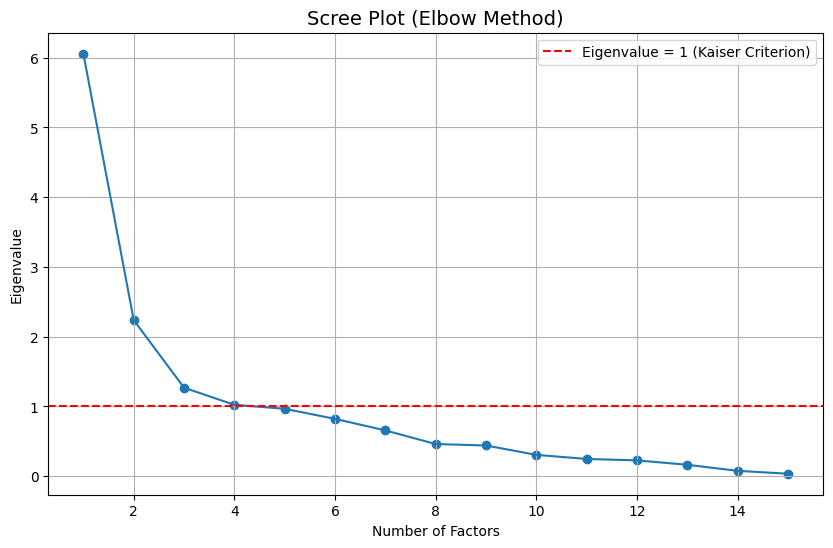

Eigenvalues: [6.05671305 2.23885396 1.26956654 1.02432327 0.96698598 0.82240771
 0.65736072 0.46178566 0.44100239 0.30664266 0.24815598 0.22754841
 0.16458327 0.07781386 0.03625652]


In [4]:
# --- Compatibility Patch for FactorAnalyzer ---
# This fixes a known issue between FactorAnalyzer and newer Scikit-Learn versions
import sklearn.utils
from sklearn.utils import check_array as original_check_array
import factor_analyzer.factor_analyzer

def patched_check_array(*args, **kwargs):
    if 'force_all_finite' in kwargs:
        kwargs['ensure_all_finite'] = kwargs.pop('force_all_finite')
    return original_check_array(*args, **kwargs)

factor_analyzer.factor_analyzer.check_array = patched_check_array
print("System Patch Applied: Compatibility fixed.")
print("-" * 30)

# --- Generate Scree Plot ---
fa = FactorAnalyzer(rotation=None)
fa.fit(df_scaled)
ev, v = fa.get_eigenvalues()

plt.figure(figsize=(10, 6))
plt.scatter(range(1, df_scaled.shape[1]+1), ev)
plt.plot(range(1, df_scaled.shape[1]+1), ev)
plt.title('Scree Plot (Elbow Method)', fontsize=14)
plt.xlabel('Number of Factors')
plt.ylabel('Eigenvalue')
plt.axhline(y=1, color='r', linestyle='--', label='Eigenvalue = 1 (Kaiser Criterion)')
plt.grid()
plt.legend()
plt.show()

print(f"Eigenvalues: {ev}")

## Factor Selection Strategy

The Scree Plot above presents a slight conflict between statistical rules:
* **Kaiser Criterion (Red Line):** Suggests 4 factors (since the 4th eigenvalue is roughly 1.0).
* **Elbow Method:** The curve flattens noticeably after the 3rd factor, suggesting 3 factors.

To resolve this, we need to look at the actual variable groupings. In the next cell, we will run both the **3-Factor** and **4-Factor** models side-by-side. We will check if the 4th factor adds meaningful economic insight or if it merely splits variables that theoretically belong together.

In [5]:
# --- Helper Functions ---
def get_loadings(df, n_factors):
    """Fits the EFA model and returns the loading matrix."""
    fa = FactorAnalyzer(n_factors=n_factors, rotation='promax')
    fa.fit(df)
    cols = [f'Factor {i+1}' for i in range(n_factors)]
    return pd.DataFrame(fa.loadings_, index=df.columns, columns=cols)

def style_matrix(df, title):
    """Applies a heatmap style to the dataframe."""
    return (df.style
            .background_gradient(cmap='RdBu', axis=None, vmin=-1, vmax=1)
            .format("{:.2f}")
            .set_caption(f'<b style="font-size:14px">{title}</b>')
            .set_properties(**{
                'width': '70px', 
                'text-align': 'center', 
                'border': '1px solid #ccc'
            }))

# --- Main Execution ---
loadings_3 = get_loadings(df_scaled, 3)
loadings_4 = get_loadings(df_scaled, 4)

# Create the HTML layout for side-by-side comparison
html_output = f"""
<div style="display: flex; gap: 20px; justify-content: flex-start;">
    <div>{style_matrix(loadings_3, "Model A: 3-Factor (S-R-E)").to_html()}</div>
    <div>{style_matrix(loadings_4, "Model B: 4-Factor (Statistical)").to_html()}</div>
</div>
"""

display(HTML(html_output))

,Factor 1,Factor 2,Factor 3
Work_Indicator,-0.70,0.29,0.08
C04_Sex,-0.18,0.09,-0.23
Available_for_Work,-0.10,0.91,0.04
Look_for_Additional_Work,0.83,0.01,0.01
Looked_for_Work_or_Tried_to_Establish_Business_During_the_Past_Week,-0.19,0.88,-0.01
Previous_Job_Indicator,0.17,0.24,0.45
Want_More_Hours_of_Work,0.71,0.03,0.03
Other_Job_Indicator,0.74,-0.00,0.01
C03_Relationship_to_Household_Head,-0.02,-0.05,0.81
C06_Marital_Status,0.21,-0.04,-0.32


## Comparative Analysis Results

Looking at the side-by-side results, we can now interpret why the 3-Factor model is better for our index:

**Why the 4-Factor Model Fails (Right Table)**
The 4-Factor structure creates an unnecessary split in the labor variables. It separates **Employment Status** (Factor 1) from **Underemployment** (Factor 3). This fragmentation is problematic because "Having a Job" and "Needing More Work" are naturally linked trade-offs, not separate economic dimensions.

**Why the 3-Factor Model Wins (Left Table)**
The 3-factor model unifies these variables into a single, logical **Employment Continuum** (Factor 1):
* **Negative Loadings:** Represent stability (High Working Hours).
* **Positive Loadings:** Represent instability (Desire for More Work).

This structure gives us a cleaner, direct measure of **Sensitivity**, scaling from "Stable Full-Time" to "High-Risk Underemployed." We therefore proceed with the 3-Factor Solution.

## Final Factor Interpretation

Based on the Pattern Matrix, we assign the final labels. Note that for all three factors, a **Higher Score** indicates **Higher Vulnerability**.

### Factor 1: Sensitivity (Labor Intensity)
* **Top Variables:** `Normal_Working_Hours` (-0.91) vs. `Look_for_Additional_Work` (+0.83).
* **Definition:** A bi-polar factor measuring the quality of employment.
    * *High Scores:* **High Sensitivity** (Respondents with low hours who actively desire more work).
    * *Low Scores:* **High Resilience** (Respondents with stable, full-time employment).

### Factor 2: Exposure (Unemployment Risk)
* **Top Variables:** `Available_for_Work` (+0.91), `Looked_for_Work` (+0.88).
* **Definition:** This factor captures the **immediate risk** of joblessness. It isolates respondents who are currently "on the market", actively looking and available for work. High scores represent **High Exposure** to labor market friction.

### Factor 3: Dependency (Demographic Instability)
* **Top Variables:** `Relationship_to_Household_Head` (+0.81), `Age` (+0.55).
* **Definition:** This factor captures structural dependency within the household.
    * *Data Note:* In the survey, `Relationship` codes increase as you move away from the Head (1=Head, 3=Son/Daughter).
    * *High Scores:* Associated with **Dependents** (Non-heads) and older dependents. This indicates **High Vulnerability** due to lower decision-making power.
    * *Low Scores:* Associated with **Household Heads**, who typically act as the economic shock buffers for the family (High Resilience).

In [ ]:
# --- FINAL MODEL & SCORING ---

# 1. Re-initialize the chosen 3-Factor Model
print("Fitting Final 3-Factor Model (S-R-E)...")
fa_final = FactorAnalyzer(n_factors=3, rotation='promax')
fa_final.fit(df_scaled)

# 2. Generate Factor Scores (Regression Method)
# This calculates the score for every single respondent in the dataset
factor_scores = fa_final.transform(df_scaled)

# 3. Create a DataFrame for the scores
# Note: Check the column order matches Factor 1/2/3 interpretation
# Based on the heatmap: F1=Sensitivity, F2=Exposure, F3=Resilience
df_scores = pd.DataFrame(factor_scores, columns=['Sensitivity_Score', 'Exposure_Score', 'Resilience_Score'])

# 4. Save the results
save_path = OUTPUT_ROOT / "Final_Factor_Scores.csv"
df_scores.to_csv(save_path, index=False)

print("-" * 30)
print(f"Factor Scores Generated Successfully.")
print(f"Data Shape: {df_scores.shape}")
print(f"Saved to: {save_path}")
print("Ready for RFVI Index Construction.")

Fitting Final 3-Factor Model (S-R-E)...
------------------------------
Factor Scores Generated Successfully.
Data Shape: (5986548, 3)
Saved to: G:\My Drive\Labor Force Survey\Factor Analysis Results\Final_Factor_Scores.csv
Ready for RFVI Index Construction.


In [7]:
print("\nFirst 20 rows of Factor Scores:")
display(df_scores.head(20))


First 20 rows of Factor Scores:


,Sensitivity_Score,Exposure_Score,Resilience_Score
0,1.263448,0.566630,1.096100
1,-1.303911,0.445294,-0.474363
2,-1.302252,0.438854,-0.630759
3,1.271089,0.555850,0.054407
4,0.766461,-1.508657,-0.178780
5,-1.289803,0.434581,-0.583726
6,0.788334,-1.586807,1.846903
7,0.754488,-1.611559,0.764422
8,0.759037,-1.619877,1.774238
9,0.760478,-1.504316,0.706516
